In [ ]:
import pandas as pd

In [ ]:
final_df = pd.read_csv("finalmodel_dataset.csv")

In [ ]:
X = final_df.drop(columns=['SK_ID_CURR', 'TARGET'])

In [ ]:
y = final_df['TARGET']

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

In [ ]:
cat_cols = X_train.select_dtypes(include=['object']).columns

In [ ]:
train_medians = X_train[num_cols].median()

In [ ]:
X_train[num_cols] = X_train[num_cols].fillna(X_train[num_cols].median())

In [ ]:
low_unique_cols = [col for col in num_cols if X_train[col].nunique() < 10]

In [ ]:
len(low_unique_cols)

146

In [ ]:
true_num_cols = [col for col in num_cols if X_train[col].nunique() >= 10]

In [ ]:
!pip install --upgrade pip
!pip install optbinning

In [ ]:
from optbinning import OptimalBinning

opt_num = {}

for col in true_num_cols:
    optb = OptimalBinning(
        name=col,
        dtype="numerical",
        monotonic_trend="auto",
        max_n_bins=5
    )

    optb.fit(X_train[col].values, y_train.values)
    opt_num[col] = optb

In [ ]:
opt_low = {}

for col in low_unique_cols:
    optb = OptimalBinning(
        name=col,
        dtype="categorical"
    )
    optb.fit(X_train[col].values.astype(str), y_train.values)
    opt_low[col] = optb

In [ ]:
from optbinning import OptimalBinning

opt_cat = {}

for col in cat_cols:
    optb = OptimalBinning(
        name=col,
        dtype="categorical"
    )

    optb.fit(X_train[col].values, y_train.values)
    opt_cat[col] = optb

In [ ]:
for col in true_num_cols:
    X_train[col] = opt_num[col].transform(X_train[col].values, metric="woe")

for col in cat_cols:
    X_train[col] = opt_cat[col].transform(X_train[col].values, metric="woe")

In [ ]:
for col in low_unique_cols:
    X_train[col] = opt_low[col].transform(X_train[col].values.astype(str), metric="woe")

In [ ]:
test_num_cols = num_cols

In [ ]:
test_cat_cols = cat_cols

In [ ]:
test_true_num_cols = true_num_cols

In [ ]:
X_test[test_num_cols] = X_test[test_num_cols].fillna(train_medians)

In [ ]:
for col in test_true_num_cols:
    X_test[col] = opt_num[col].transform(X_test[col].values, metric="woe")

In [ ]:
for col in test_cat_cols:
    X_test[col] = opt_cat[col].transform(X_test[col].values, metric="woe")

In [ ]:
for col in low_unique_cols:
    X_test[col] = opt_low[col].transform(X_test[col].values.astype(str), metric="woe")

In [ ]:
iv_values = {}

for col in true_num_cols:
    bt = opt_num[col].binning_table
    bt.build()
    iv_values[col] = bt.iv

for col in low_unique_cols:
    bt = opt_low[col].binning_table
    bt.build()
    iv_values[col] = bt.iv

for col in cat_cols:
    bt = opt_cat[col].binning_table
    bt.build()
    iv_values[col] = bt.iv

iv_df = pd.DataFrame.from_dict(iv_values, orient='index', columns=['IV'])
iv_df = iv_df.sort_values('IV', ascending=False)
pd.set_option('display.max_rows', None)
print(iv_df)

                                         IV
EXT_SOURCE_3                       0.317054
EXT_SOURCE_2                       0.304955
EXT_SOURCE_1                       0.143746
DAYS_EMPLOYED                      0.111253
DAYS_BIRTH                         0.087233
AMT_GOODS_PRICE                    0.083512
OCCUPATION_TYPE                    0.066600
NAME_INCOME_TYPE                   0.055898
AMT_CREDIT                         0.054549
REGION_RATING_CLIENT_W_CITY        0.051572
ORGANIZATION_TYPE                  0.050878
REGION_RATING_CLIENT               0.048177
NAME_EDUCATION_TYPE                0.048024
DAYS_LAST_PHONE_CHANGE             0.044979
CODE_GENDER                        0.038423
DAYS_ID_PUBLISH                    0.036664
TOTALAREA_MODE                     0.036149
REGION_POPULATION_RELATIVE         0.034847
FLAG_EMP_PHONE                     0.033591
REG_CITY_NOT_WORK_CITY             0.033039
LIVINGAREA_AVG                     0.029752
LIVINGAREA_MODE                 

In [ ]:
selected_features = iv_df[iv_df['IV'] >= 0.02].index.tolist()
X_train = X_train[selected_features]
X_test = X_test[selected_features]

print(f"Features before: 267")
print(f"Features after: {len(selected_features)}")

Features before: 267
Features after: 78


In [ ]:
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

TARGET
0    226148
1     19860
Name: count, dtype: int64
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    C=0.1,
    random_state=42,
    max_iter=1000,

)

lr.fit(X_train, y_train)

LogisticRegression(C=0.1, max_iter=1000, penalty='l1', random_state=42,
                   solver='liblinear')

KS statistic — maximum separation between defaulters and non-defaulters

Cumulative % of each group as we move from lowest to highest predicted default probability

KS = maximum vertical gap between the two curves. Bigger gap = better model separation.

Gini coefficient — how far your model is from random

Cumulative % of actual defaulters captured as we move through customers ranked by predicted risk

Gini = area between your model curve and the random diagonal, as a ratio. Higher = better.

In [ ]:
from sklearn.metrics import roc_auc_score
import numpy as np

y_pred_prob = lr.predict_proba(X_test)[:, 1]

# AUC
auc = roc_auc_score(y_test, y_pred_prob)
gini = 2 * auc - 1

# KS Statistic
from scipy.stats import ks_2samp
defaults = y_pred_prob[y_test == 1]
non_defaults = y_pred_prob[y_test == 0]
ks_stat, _ = ks_2samp(defaults, non_defaults)

print(f"AUC:   {auc:.4f}")
print(f"Gini:  {gini:.4f}")
print(f"KS:    {ks_stat:.4f}")

AUC:   0.7471
Gini:  0.4943
KS:    0.3709


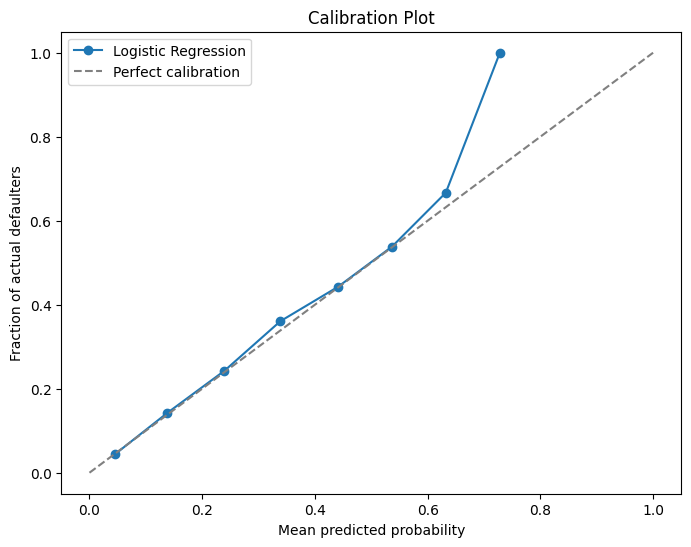

In [ ]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

fraction_of_positives, mean_predicted_value = calibration_curve(
    y_test, y_pred_prob, n_bins=10
)

plt.figure(figsize=(8, 6))
plt.plot(mean_predicted_value, fraction_of_positives,
         marker='o', label='Logistic Regression')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of actual defaulters')
plt.title('Calibration Plot')
plt.legend()
plt.show()

In [ ]:
# PDO Scaling parameters
PDO = 20
base_score = 600
base_odds = 50

In [ ]:
# Calculate scaling factors
factor = PDO / np.log(2)
offset = base_score - (factor * np.log(base_odds))

In [ ]:
# Convert predicted probabilities to scores
y_pred_prob = lr.predict_proba(X_test)[:, 1]

log_odds = np.log((1 - y_pred_prob) / y_pred_prob)

scores = offset + factor * log_odds
scores = scores.round().astype(int)

print(f"Min score: {scores.min()}")
print(f"Max score: {scores.max()}")
print(f"Mean score: {scores.mean():.0f}")

Min score: 459
Max score: 663
Mean score: 568


In [ ]:
# Score band distribution
import pandas as pd

score_df = pd.DataFrame({
    'score': scores,
    'actual': y_test.values
})

bins = [0, 500, 520, 540, 560, 580, 600, 620, 640, 700]
labels = ['<500', '500-520', '520-540', '540-560', '560-580', '580-600', '600-620', '620-640', '640+']

score_df['score_band'] = pd.cut(score_df['score'], bins=bins, labels=labels)

band_summary = score_df.groupby('score_band', observed=True).agg(
    total_customers=('actual', 'count'),
    total_defaults=('actual', 'sum')
).reset_index()

band_summary['default_rate'] = (band_summary['total_defaults'] / band_summary['total_customers'] * 100).round(1)
band_summary['default_rate'] = band_summary['default_rate'].astype(str) + '%'

print(band_summary.to_string(index=False))

score_band  total_customers  total_defaults default_rate
      <500              431             193        44.8%
   500-520             2254             694        30.8%
   520-540             7232            1307        18.1%
   540-560            14287            1409         9.9%
   560-580            17413             919         5.3%
   580-600            13101             344         2.6%
   600-620             5549              85         1.5%
   620-640             1128              13         1.2%
      640+              108               1         0.9%


In [ ]:
# Customer level score output
score_output = pd.DataFrame({
    'SK_ID_CURR': final_df.loc[y_test.index, 'SK_ID_CURR'].values,
    'TARGET': y_test.values,
    'DEFAULT_PROBABILITY': y_pred_prob.round(4),
    'CREDIT_SCORE': scores
})

score_output = score_output.sort_values('CREDIT_SCORE', ascending=False).reset_index(drop=True)

print(score_output.head(10))

   SK_ID_CURR  TARGET  DEFAULT_PROBABILITY  CREDIT_SCORE
0      100889       0               0.0022           663
1      321771       0               0.0024           662
2      264039       0               0.0024           661
3      175620       0               0.0026           659
4      339432       0               0.0027           658
5      272654       0               0.0028           657
6      160276       0               0.0029           656
7      172286       0               0.0028           656
8      189844       0               0.0029           656
9      405268       0               0.0029           656


In [ ]:
# Scorecard points per feature
coefficients = pd.Series(lr.coef_[0], index=X_train.columns)
intercept = lr.intercept_[0]

scorecard = pd.DataFrame({
    'feature': coefficients.index,
    'coefficient': coefficients.values,
    'points': -(coefficients.values * factor).round(0).astype(int)
})

scorecard = scorecard.sort_values('points', ascending=False).reset_index(drop=True)

print(f"Intercept points: {-(intercept * factor + offset).round(0).astype(int)}")
print()
print(scorecard.to_string(index=False))

Intercept points: -417

                          feature  coefficient  points
                     EXT_SOURCE_3    -0.778626      22
                      AVG_BALANCE    -0.773067      22
                     EXT_SOURCE_2    -0.729228      21
                  FLAG_DOCUMENT_3    -0.648783      19
               ACTIVE_LOANS_COUNT    -0.671388      19
                      CODE_GENDER    -0.628569      18
                      OWN_CAR_AGE    -0.600457      17
                  AMT_GOODS_PRICE    -0.504381      15
                   MAX_CREDIT_SUM    -0.512747      15
              NAME_EDUCATION_TYPE    -0.509904      15
                     EXT_SOURCE_1    -0.464409      13
                    DAYS_EMPLOYED    -0.420574      12
                ORGANIZATION_TYPE    -0.333659      10
                      AMT_ANNUITY    -0.359324      10
                DAYS_REGISTRATION    -0.282466       8
           REG_CITY_NOT_LIVE_CITY    -0.263545       8
      REGION_RATING_CLIENT_W_CITY    -0.2

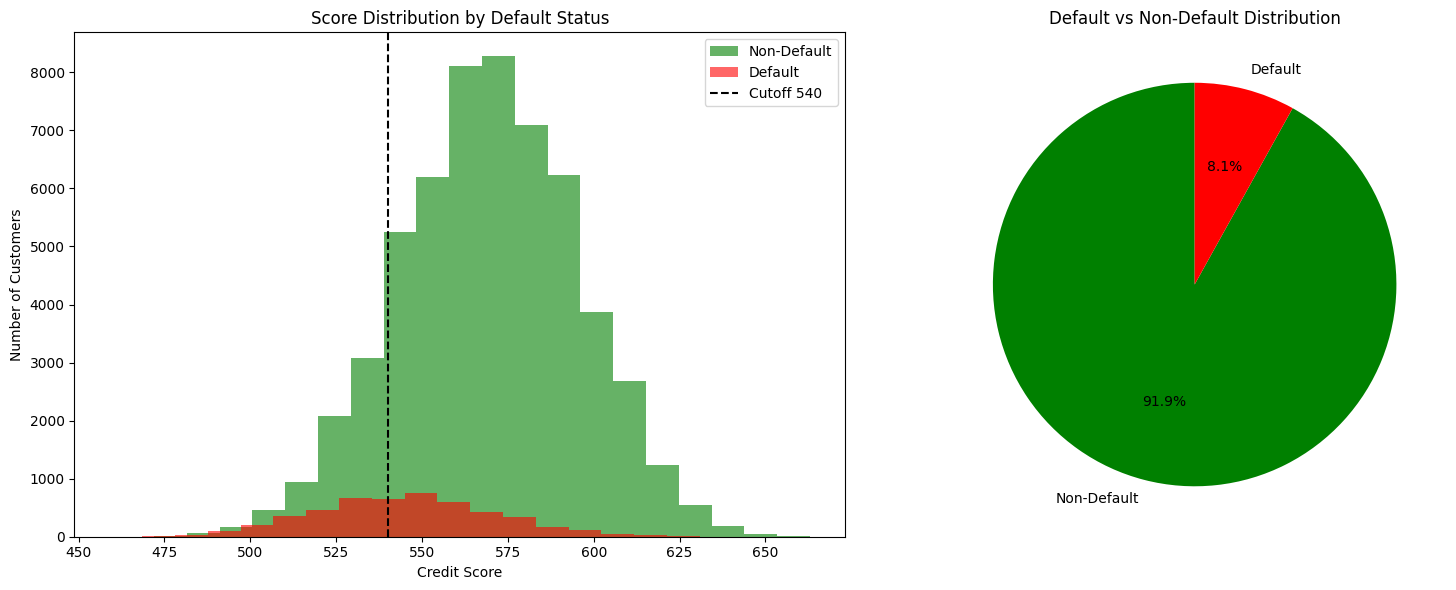

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram — score distribution by default status
defaults = score_output[score_output['TARGET'] == 1]['CREDIT_SCORE']
non_defaults = score_output[score_output['TARGET'] == 0]['CREDIT_SCORE']

axes[0].hist(non_defaults, bins=20, color='green', alpha=0.6, label='Non-Default')
axes[0].hist(defaults, bins=20, color='red', alpha=0.6, label='Default')
axes[0].axvline(x=540, color='black', linestyle='--', label='Cutoff 540')
axes[0].set_title('Score Distribution by Default Status')
axes[0].set_xlabel('Credit Score')
axes[0].set_ylabel('Number of Customers')
axes[0].legend()

# Pie chart — overall split
status_counts = score_output['TARGET'].value_counts()
axes[1].pie(status_counts, labels=['Non-Default', 'Default'],
            colors=['green', 'red'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Default vs Non-Default Distribution')

plt.tight_layout()
plt.show()

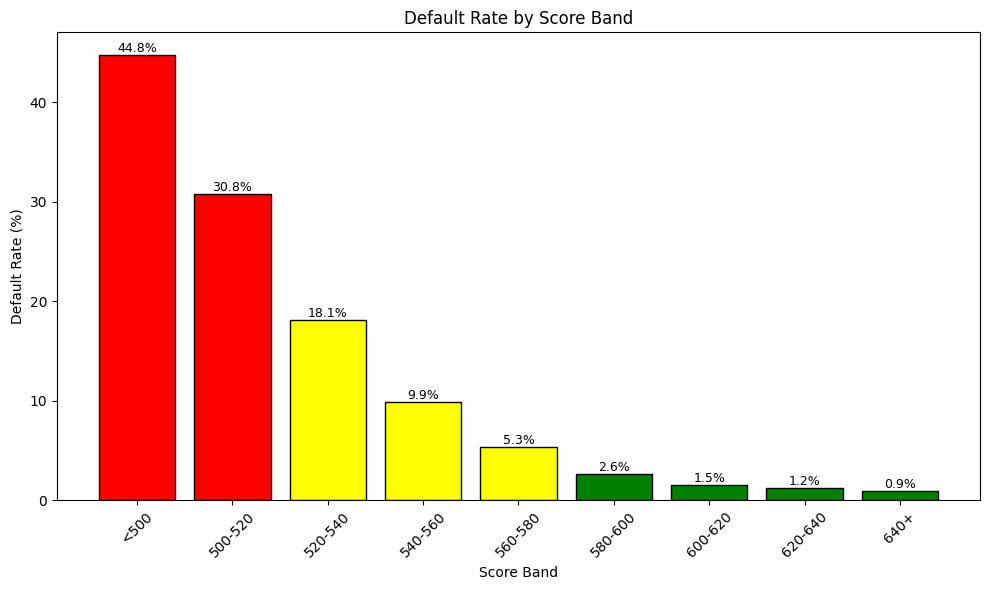

In [ ]:
plt.figure(figsize=(10, 6))

bar_colors = []
for rate in band_summary_plot['default_rate']:
    if rate >= 20:
        bar_colors.append('red')
    elif rate >= 5:
        bar_colors.append('yellow')
    else:
        bar_colors.append('green')

plt.bar(band_summary_plot['score_band'].astype(str),
        band_summary_plot['default_rate'],
        color=bar_colors, edgecolor='black')
plt.title('Default Rate by Score Band')
plt.xlabel('Score Band')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=45)
for i, v in enumerate(band_summary_plot['default_rate']):
    plt.text(i, v + 0.3, f'{v}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()